In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True)
df = housing.data
df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df = df.fillna(df.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('MedHouseVal', axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=housing.feature_names)

print("Feature Engineering Selesai")

Feature Engineering Selesai


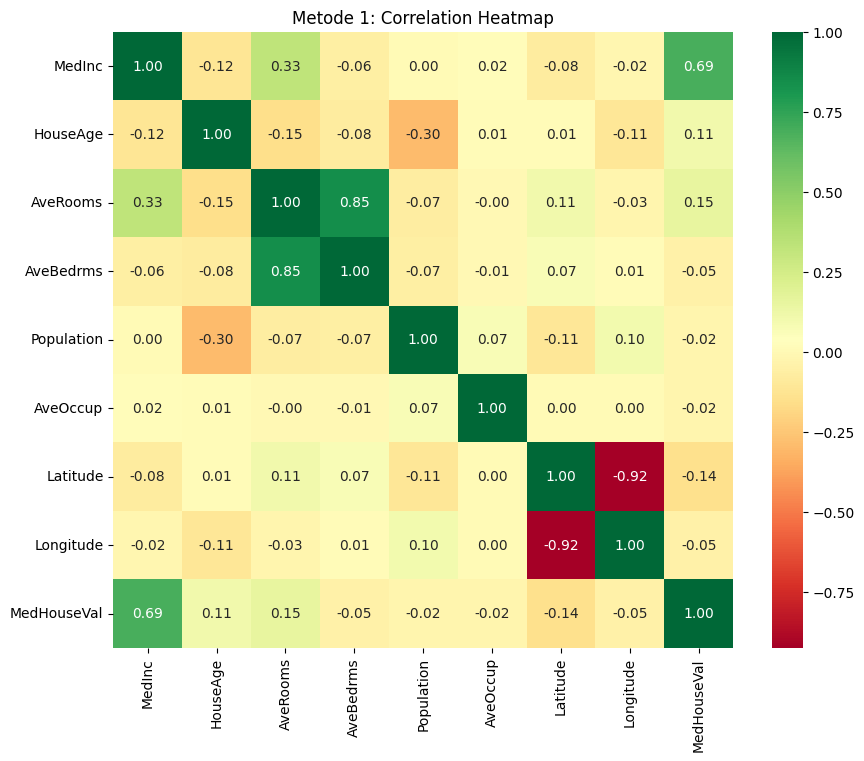

Metode 2: Univariate Selection
Fitur terbaik: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude']


In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Metode 1: Correlation Heatmap")
plt.show()

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X, y)

cols = selector.get_support(indices=True)
fitur_terpilih = X.iloc[:,cols].columns.tolist()

print("Metode 2: Univariate Selection")
print("Fitur terbaik:", fitur_terpilih)

In [4]:
print("Interpretasi Hasil:")
print("1. Feature Engineering: Data telah dibersihkan dari nilai kosong menggunakan median dan disamakan skalanya dengan StandardScaler.")
print("2. Feature Selection (Correlation): Fitur MedInc memiliki korelasi terkuat dengan harga rumah.")
print("3. Feature Selection (Univariate): Lima fitur paling berpengaruh telah dipilih untuk mengoptimalkan kinerja model.")

Interpretasi Hasil:
1. Feature Engineering: Data telah dibersihkan dari nilai kosong menggunakan median dan disamakan skalanya dengan StandardScaler.
2. Feature Selection (Correlation): Fitur MedInc memiliki korelasi terkuat dengan harga rumah.
3. Feature Selection (Univariate): Lima fitur paling berpengaruh telah dipilih untuk mengoptimalkan kinerja model.
